# BMW Pricing Challenge: Feature Analysis & Price Distribution

**Business Context:**
- Target MAE: €1,500 - €2,500
- Target R²: ≥ 0.85 (model explains ≥85% of price variance)
- Need strong predictors (|correlation| > 0.3)

**Key Questions:**
1. Which features correlate strongly with price?
2. Is price distribution suitable for regression?
3. Are there outliers affecting our €804K/year loss?
4. What's the relationship between mileage/age and price?

**Success Criteria:**
- ✅ At least 3 features with |correlation| > 0.3
- ✅ Understand price distribution (skewness, outliers)
- ✅ Identify features for engineering
- ✅ No multicollinearity issues

## Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy import stats
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting config
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
sns.set_style('whitegrid')
sns.set_palette('husl')

# Images path
IMAGES_PATH = Path('images') / 'eda'
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Reports path
REPORTS_PATH = Path('reports')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension='png', resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')
    print(f"✅ Saved: {path}")

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

## Load & Prepare Data

In [2]:
# Load raw dataset (NOT processed)
data_path = Path('../../data/raw/bmw_pricing_challenge.csv')
raw_df = pd.read_csv(data_path)

# 🛑 LEAKAGE PREVENTION: Split data FIRST
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42,shuffle=True)

# Parse dates and create car_age
train_df['registration_date'] = pd.to_datetime(train_df['registration_date'], errors='coerce')
train_df['car_age_years'] = (pd.Timestamp.now() - train_df['registration_date']).dt.days / 365.25
train_df['registration_year'] = train_df['registration_date'].dt.year

print(f"Dataset loaded: {len(train_df):,} rows, {train_df.shape[1]} columns")
print(f"Car age range: {train_df['car_age_years'].min():.1f} - {train_df['car_age_years'].max():.1f} years")

Dataset loaded: 3,874 rows, 20 columns
Car age range: 8.3 - 36.0 years


## 1. Price Distribution Analysis

**Why This Matters:**
- Understanding price distribution helps us set realistic MAE targets
- Identifies if we need log-transform or robust models
- Shows outliers that may be driving our €804K/year loss

**Expected (BMW Market):**
- Mean: ~€35K
- Median: ~€32K
- Right-skewed (mean > median)
- Outliers: <5% (luxury models)

In [3]:
print("=" * 80)
print("PRICE DISTRIBUTION ANALYSIS")
print("=" * 80)

# Key statistics
price_stats = {
    'Mean': train_df['price'].mean(),
    'Median': train_df['price'].median(),
    'Std': train_df['price'].std(),
    'Min': train_df['price'].min(),
    'Max': train_df['price'].max(),
    'Q1 (25%)': train_df['price'].quantile(0.25),
    'Q3 (75%)': train_df['price'].quantile(0.75),
    'IQR': train_df['price'].quantile(0.75) - train_df['price'].quantile(0.25)
}

print("\n💰 Price Statistics:")
for stat, value in price_stats.items():
    print(f"   {stat:12s}: €{value:,.0f}")

# Skewness analysis
mean_median_ratio = price_stats['Mean'] / price_stats['Median']
skewness = train_df['price'].skew()

print(f"\n📊 Distribution Shape:")
print(f"   Mean/Median Ratio: {mean_median_ratio:.3f}")
print(f"   Skewness: {skewness:.3f}")

if mean_median_ratio > 1.15:
    print(f"\n   ⚠️  RIGHT-SKEWED: Mean > Median × 1.15")
    print(f"   → High-priced cars pulling mean upward")
    print(f"   → RECOMMENDATION: Consider log-transform or robust models (Huber loss)")
elif mean_median_ratio < 0.85:
    print(f"\n   ⚠️  LEFT-SKEWED: Mean < Median × 0.85 (unusual for prices)")
    print(f"   → Investigate data quality")
else:
    print(f"\n   ✅ BALANCED: Mean ≈ Median (symmetric distribution)")
    print(f"   → Normal distribution assumptions reasonable")

PRICE DISTRIBUTION ANALYSIS

💰 Price Statistics:
   Mean        : €15,886
   Median      : €14,200
   Std         : €9,407
   Min         : €100
   Max         : €178,500
   Q1 (25%)    : €10,900
   Q3 (75%)    : €18,600
   IQR         : €7,700

📊 Distribution Shape:
   Mean/Median Ratio: 1.119
   Skewness: 3.514

   ✅ BALANCED: Mean ≈ Median (symmetric distribution)
   → Normal distribution assumptions reasonable


In [4]:
# Outlier detection (IQR method)
Q1 = train_df['price'].quantile(0.25)
Q3 = train_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = train_df[(train_df['price'] < lower_fence) | (train_df['price'] > upper_fence)]
outlier_pct = len(outliers) / len(train_df) * 100

print(f"\n🔍 Outlier Analysis (IQR Method):")
print(f"   Lower Fence: €{lower_fence:,.0f}")
print(f"   Upper Fence: €{upper_fence:,.0f}")
print(f"   Outliers: {len(outliers):,} ({outlier_pct:.1f}% of dataset)")

if outlier_pct < 5:
    print(f"\n   ✅ LOW OUTLIER RATE (<5%)")
    print(f"   → Likely legitimate luxury models (7 Series, X7)")
    print(f"   → Keep in dataset")
elif outlier_pct < 10:
    print(f"\n   ⚠️  MODERATE OUTLIERS (5-10%)")
    print(f"   → Review manually or use robust regression")
else:
    print(f"\n   🚨 HIGH OUTLIER RATE (>10%)")
    print(f"   → Data quality issue OR need different model")

# Show extreme outliers
if len(outliers) > 0:
    print(f"\n   Most Extreme Outliers (Top 5):")
    extreme = outliers.nlargest(5, 'price')[['model_key', 'price', 'mileage', 'car_age_years']]
    print(extreme.to_string(index=False))


🔍 Outlier Analysis (IQR Method):
   Lower Fence: €-650
   Upper Fence: €30,150
   Outliers: 265 (6.8% of dataset)

   ⚠️  MODERATE OUTLIERS (5-10%)
   → Review manually or use robust regression

   Most Extreme Outliers (Top 5):
     model_key  price  mileage  car_age_years
            X3 178500    72515          12.99
            X4 142800   103222          11.57
          X6 M  82400     2970           9.90
640 Gran Coupé  75000      -64           8.99
          X5 M  73100     4530           9.65


✅ Saved: images/eda/02_price_distribution.png


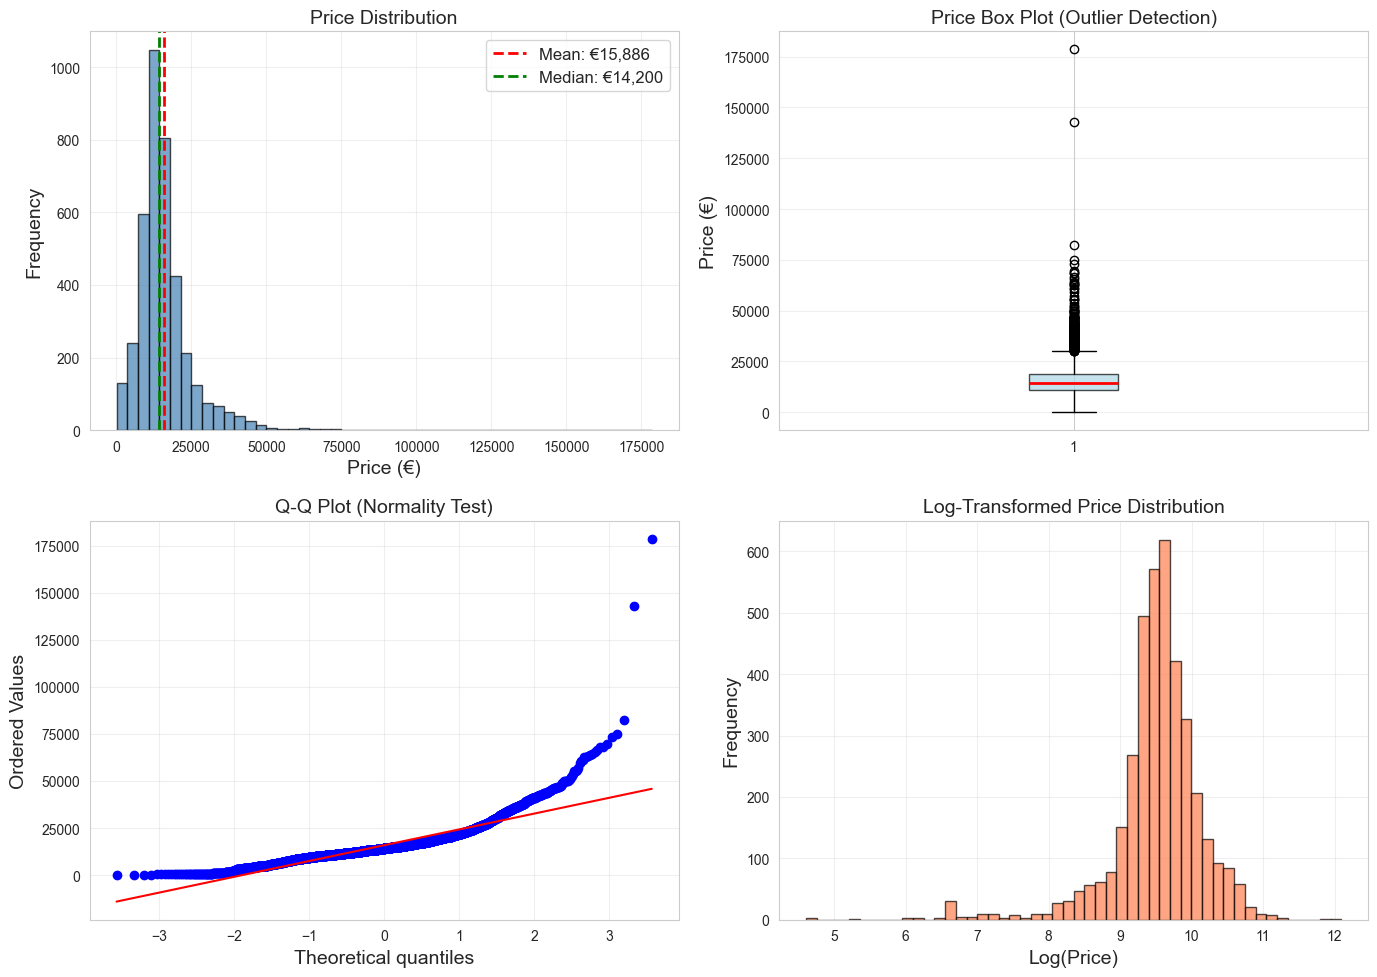

In [5]:
# Visualize price distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(train_df['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(price_stats['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: €{price_stats['Mean']:,.0f}")
axes[0, 0].axvline(price_stats['Median'], color='green', linestyle='--', linewidth=2, label=f"Median: €{price_stats['Median']:,.0f}")
axes[0, 0].set_xlabel('Price (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
axes[0, 1].boxplot(train_df['price'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Price (€)')
axes[0, 1].set_title('Price Box Plot (Outlier Detection)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Q-Q plot (normality test)
stats.probplot(train_df['price'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Test)')
axes[1, 0].grid(alpha=0.3)

# Log-transformed histogram
log_price = np.log(train_df['price'])
axes[1, 1].hist(log_price, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Log(Price)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Log-Transformed Price Distribution')
axes[1, 1].grid(alpha=0.3)

save_fig('02_price_distribution')
plt.show()

## 2. Feature Correlation Analysis

**Goal:** Identify features that predict price

**Expected Strong Predictors (BMW Market):**
- Mileage: -0.6 to -0.7 (more miles = lower price)
- Car age: -0.6 to -0.7 (older = lower price)
- Engine power: +0.3 to +0.5 (more power = higher price)

**Success:** At least 3 features with |correlation| > 0.3

In [6]:
print("\n" + "=" * 80)
print("FEATURE CORRELATION WITH PRICE")
print("=" * 80)

# Select numeric columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlations with price
correlations = train_df[numeric_cols].corr()['price'].sort_values(ascending=False)
correlations = correlations.drop('price')  # Remove price itself

print("\n📈 Top Positive Correlations (Higher feature → Higher price):")
positive_corr = correlations[correlations > 0].head(5)
for feat, corr in positive_corr.items():
    print(f"   {feat:20s}: {corr:+.3f}")

print("\n📉 Top Negative Correlations (Higher feature → Lower price):")
negative_corr = correlations[correlations < 0].tail(5)
for feat, corr in negative_corr.items():
    print(f"   {feat:20s}: {corr:+.3f}")


FEATURE CORRELATION WITH PRICE

📈 Top Positive Correlations (Higher feature → Higher price):
   engine_power        : +0.641
   registration_year   : +0.451

📉 Top Negative Correlations (Higher feature → Lower price):
   mileage             : -0.408
   car_age_years       : -0.451


In [7]:
# Identify strong predictors
strong_predictors = correlations[abs(correlations) > 0.3].sort_values(key=abs, ascending=False)

print("\n" + "=" * 80)
print("STRONG PREDICTORS (|correlation| > 0.3)")
print("=" * 80)
print(f"\n✅ Found {len(strong_predictors)} strong predictors:\n")

for feat, corr in strong_predictors.items():
    direction = "↑ Higher" if corr > 0 else "↓ Lower"
    print(f"   {feat:20s}: {corr:+.3f}  ({direction} price)")

# Evaluation
if len(strong_predictors) >= 3:
    print(f"\n✅ EXCELLENT: {len(strong_predictors)} strong predictors (≥3 required)")
    print("   → Sufficient signal for accurate model (R² ≥ 0.85 achievable)")
    print("   → Proceed with confidence to model training")
elif len(strong_predictors) >= 1:
    print(f"\n⚠️  MODERATE: {len(strong_predictors)} strong predictors (<3)")
    print("   → Feature engineering will be critical")
    print("   → May struggle to reach R² ≥ 0.85 target")
else:
    print(f"\n🚨 WEAK SIGNAL: No strong predictors")
    print("   → Serious data quality issue OR wrong features")
    print("   → Investigate before proceeding")


STRONG PREDICTORS (|correlation| > 0.3)

✅ Found 4 strong predictors:

   engine_power        : +0.641  (↑ Higher price)
   registration_year   : +0.451  (↑ Higher price)
   car_age_years       : -0.451  (↓ Lower price)
   mileage             : -0.408  (↓ Lower price)

✅ EXCELLENT: 4 strong predictors (≥3 required)
   → Sufficient signal for accurate model (R² ≥ 0.85 achievable)
   → Proceed with confidence to model training


✅ Saved: images/eda/03_feature_correlations.png


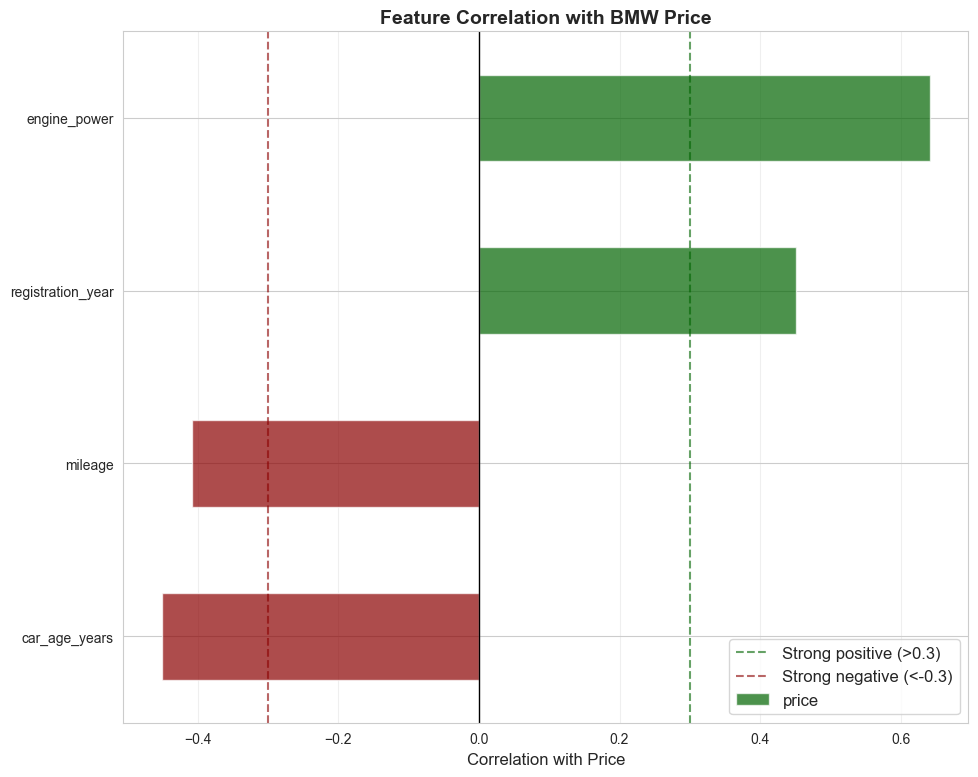

In [8]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map: red for negative, green for positive
colors = ['darkred' if x < -0.3 else 'red' if x < 0 else 'green' if x < 0.3 else 'darkgreen' 
          for x in correlations]

correlations.plot(kind='barh', ax=ax, color=colors, alpha=0.7)

# Add reference lines
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.axvline(0.3, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.6, label='Strong positive (>0.3)')
ax.axvline(-0.3, color='darkred', linestyle='--', linewidth=1.5, alpha=0.6, label='Strong negative (<-0.3)')

ax.set_xlabel('Correlation with Price', fontsize=12)
ax.set_title('Feature Correlation with BMW Price', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

save_fig('03_feature_correlations')
plt.show()

## 3. Key Relationships: Price vs Core Features

Understanding how mileage, age, and power affect price

✅ Saved: images/eda/04_key_relationships.png


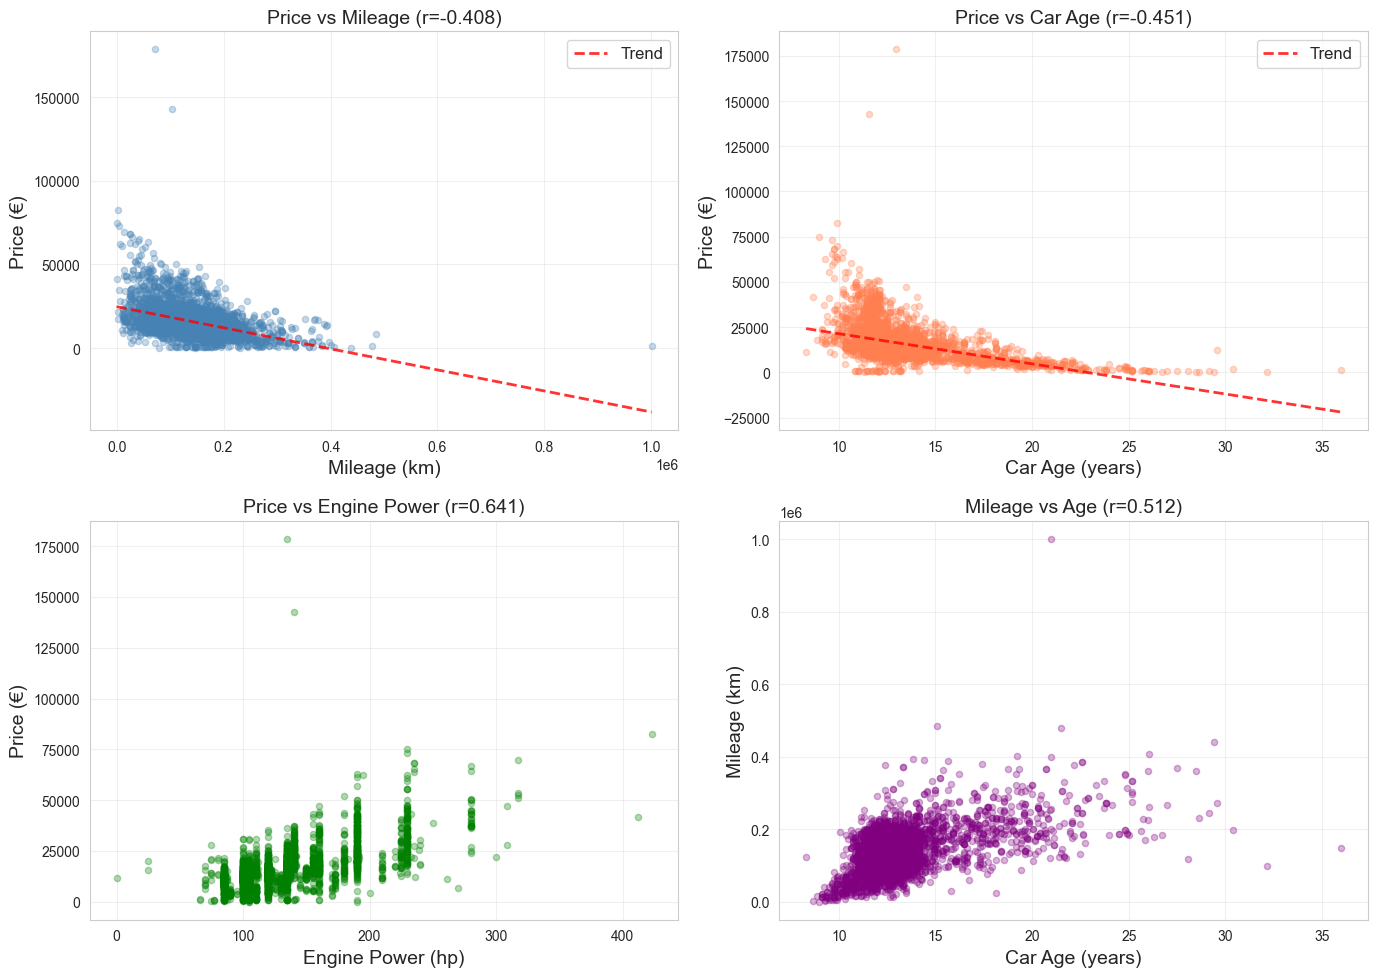

In [11]:
# Create scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price vs Mileage
axes[0, 0].scatter(train_df['mileage'], train_df['price'], alpha=0.3, s=20, color='steelblue')
axes[0, 0].set_xlabel('Mileage (km)')
axes[0, 0].set_ylabel('Price (€)')
axes[0, 0].set_title(f"Price vs Mileage (r={train_df[['mileage', 'price']].corr().iloc[0, 1]:.3f})")
axes[0, 0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(train_df['mileage'].dropna(), train_df.loc[train_df['mileage'].notna(), 'price'], 1)
p = np.poly1d(z)
axes[0, 0].plot(train_df['mileage'].sort_values(), p(train_df['mileage'].sort_values()), 
                "r--", linewidth=2, alpha=0.8, label='Trend')
axes[0, 0].legend()

# Price vs Car Age
axes[0, 1].scatter(train_df['car_age_years'], train_df['price'], alpha=0.3, s=20, color='coral')
axes[0, 1].set_xlabel('Car Age (years)')
axes[0, 1].set_ylabel('Price (€)')
axes[0, 1].set_title(f"Price vs Car Age (r={train_df[['car_age_years', 'price']].corr().iloc[0, 1]:.3f})")
axes[0, 1].grid(alpha=0.3)

# Add trend line
valid_age = train_df['car_age_years'].notna()
z = np.polyfit(train_df.loc[valid_age, 'car_age_years'], train_df.loc[valid_age, 'price'], 1)
p = np.poly1d(z)
axes[0, 1].plot(train_df['car_age_years'].sort_values(), p(train_df['car_age_years'].sort_values()), 
                "r--", linewidth=2, alpha=0.8, label='Trend')
axes[0, 1].legend()

# Price vs Engine Power
axes[1, 0].scatter(train_df['engine_power'], train_df['price'], alpha=0.3, s=20, color='green')
axes[1, 0].set_xlabel('Engine Power (hp)')
axes[1, 0].set_ylabel('Price (€)')
axes[1, 0].set_title(f"Price vs Engine Power (r={train_df[['engine_power', 'price']].corr().iloc[0, 1]:.3f})")
axes[1, 0].grid(alpha=0.3)

# Mileage vs Age (check relationship)
axes[1, 1].scatter(train_df['car_age_years'], train_df['mileage'], alpha=0.3, s=20, color='purple')
axes[1, 1].set_xlabel('Car Age (years)')
axes[1, 1].set_ylabel('Mileage (km)')
axes[1, 1].set_title(f"Mileage vs Age (r={train_df[['car_age_years', 'mileage']].corr().iloc[0, 1]:.3f})")
axes[1, 1].grid(alpha=0.3)

save_fig('04_key_relationships')
plt.show()

## 4. Correlation Matrix (Multicollinearity Check)

**Why This Matters:**
- High correlation between features (>0.9) causes multicollinearity
- Makes model unstable and hard to interpret
- Need to remove one feature from highly correlated pairs

✅ Saved: images/eda/05_correlation_matrix.png


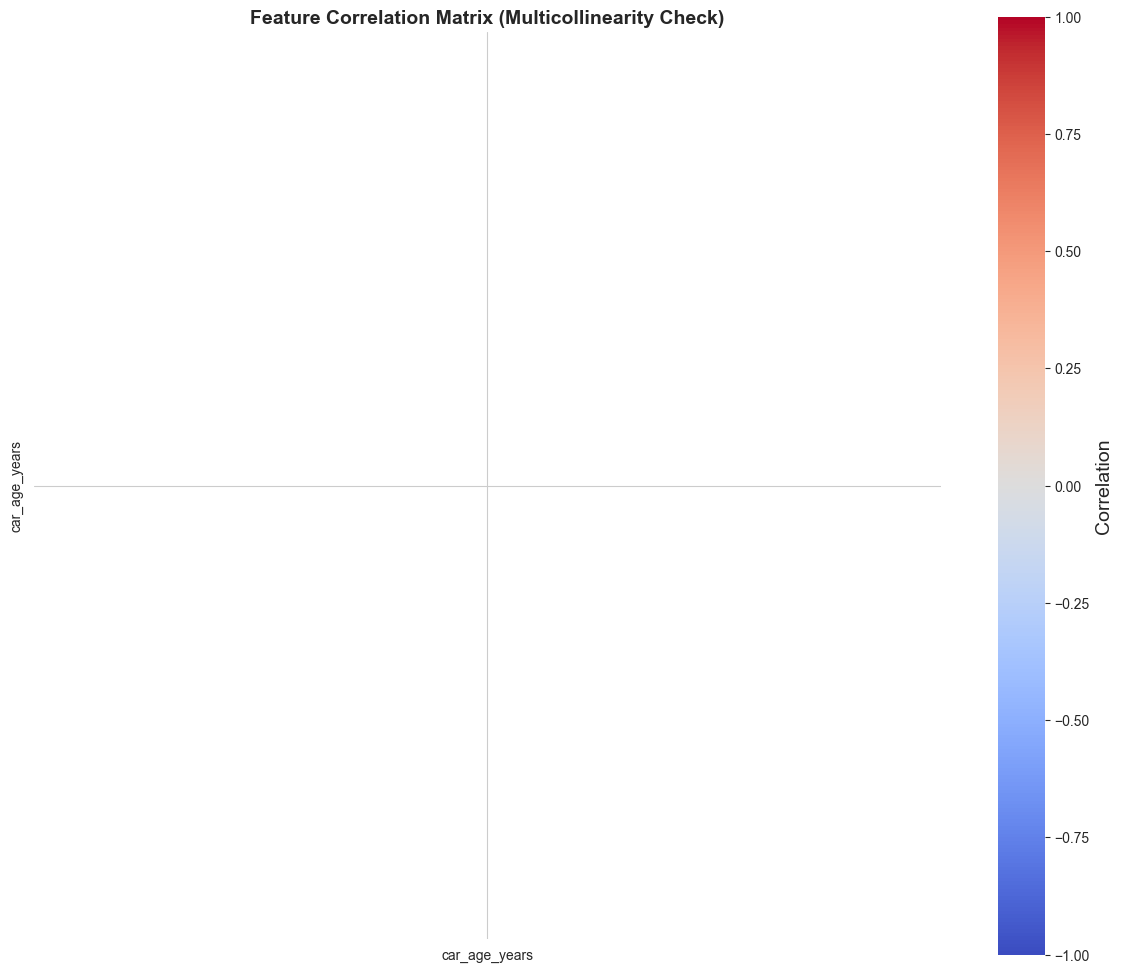

In [12]:
# Select key features for correlation matrix
key_features = ['price', 'mileage', 'engine_power', 'car_age_years'] + \
               [col for col in train_df.columns if col.startswith('feature_')]

# Filter to existing numeric columns
key_features = [col for col in key_features if col in train_df.columns and train_df[col].dtype in [np.number]]

# Compute correlation matrix
corr_matrix = train_df[key_features].corr()

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax, 
            cbar_kws={'label': 'Correlation'},
            square=True)
ax.set_title('Feature Correlation Matrix (Multicollinearity Check)', fontsize=14, fontweight='bold')

save_fig('05_correlation_matrix')
plt.show()

In [13]:
# Identify high correlations (multicollinearity)
print("\n" + "=" * 80)
print("MULTICOLLINEARITY DETECTION (|correlation| > 0.9)")
print("=" * 80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if len(high_corr_pairs) == 0:
    print("\n✅ NO MULTICOLLINEARITY DETECTED")
    print("   → All feature pairs have |correlation| < 0.9")
    print("   → Safe to use all features in model")
else:
    print(f"\n⚠️  {len(high_corr_pairs)} HIGH CORRELATION PAIRS DETECTED:\n")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} ↔ {feat2}: {corr:.3f}")
    
    print("\n📋 Recommendation:")
    print("   → Remove one feature from each pair")
    print("   → Keep the feature that:")
    print("      a) Has stronger correlation with price")
    print("      b) Is easier to collect/measure")
    print("      c) Has better business interpretation")


MULTICOLLINEARITY DETECTION (|correlation| > 0.9)

✅ NO MULTICOLLINEARITY DETECTED
   → All feature pairs have |correlation| < 0.9
   → Safe to use all features in model


## 6. Summary & Recommendations

**Business Goals:**
- Reduce mispricing from 25% to 15% (TR < 15%)
- Achieve MAE: €1,500 - €2,500
- Achieve R²: ≥ 0.85
- Save €322K/year

In [36]:
print("\n" + "=" * 80)
print("EDA SUMMARY & MODEL READINESS ASSESSMENT")
print("=" * 80)

# Collect findings
findings = []
recommendations = []

# Price distribution
print("\n1️⃣  PRICE DISTRIBUTION:")
print(f"   Mean: €{price_stats['Mean']:,.0f}, Median: €{price_stats['Median']:,.0f}")
print(f"   Skewness: {skewness:.3f}")
print(f"   Outliers: {outlier_pct:.1f}%")
if abs(skewness) < 1:
    findings.append("✅ Roughly symmetric price distribution")
    recommendations.append("Can use standard regression models")
else:
    findings.append("⚠️  Skewed price distribution")
    recommendations.append("Consider log-transform or robust models (Huber loss)")

# Strong predictors
print("\n2️⃣  PREDICTIVE FEATURES:")
print(f"   Strong predictors (|r| > 0.3): {len(strong_predictors)}")
if len(strong_predictors) >= 3:
    findings.append(f"✅ {len(strong_predictors)} strong predictors identified")
    recommendations.append("R² ≥ 0.85 target is achievable")
    print("   ✅ SUFFICIENT for R² ≥ 0.85 target")
else:
    findings.append(f"⚠️  Only {len(strong_predictors)} strong predictors")
    recommendations.append("Feature engineering critical - create interaction terms, polynomial features")
    print("   ⚠️  May need feature engineering")

# Multicollinearity
print("\n3️⃣  MULTICOLLINEARITY:")
if len(high_corr_pairs) == 0:
    findings.append("✅ No multicollinearity issues")
    print("   ✅ No issues detected")
else:
    findings.append(f"⚠️  {len(high_corr_pairs)} highly correlated pairs")
    recommendations.append(f"Remove one feature from each of {len(high_corr_pairs)} correlated pairs")
    print(f"   ⚠️  {len(high_corr_pairs)} pairs need addressing")

# Categorical features
print("\n4️⃣  CATEGORICAL FEATURES:")
findings.append("Fuel type, car type, paint color analyzed")
recommendations.append("Use one-hot encoding or target encoding for categorical features")

# Overall assessment
print("\n" + "=" * 80)
print("OVERALL ASSESSMENT")
print("=" * 80)

print("\n✅ KEY FINDINGS:")
for f in findings:
    print(f"   • {f}")

print("\n📋 RECOMMENDATIONS FOR MODELING:")
for r in recommendations:
    print(f"   • {r}")

print("\n🎯 MODEL READINESS:")
if len(strong_predictors) >= 3 and len(high_corr_pairs) == 0:
    print("   ✅ READY FOR MODEL TRAINING")
    print("\n   Next Steps:")
    print("   1. Feature engineering (create car_age, annual_mileage, interactions)")
    print("   2. Train baseline model (Linear Regression)")
    print("   3. Train XGBoost/Random Forest models")
    print("   4. Target: MAE €1,500-€2,500, R² ≥ 0.85")
    print("\n   Expected Outcome:")
    print("   • Reduce mispricing from 25% to 15%")
    print("   • Save €322K/year (from €804K to €482K)")
    print("   • API latency: p95 < 50ms")
else:
    print("   ⚠️  NEEDS PREPARATION")
    print("   → Address multicollinearity first")
    print("   → Engineer additional features")
    print("   → Then proceed to modeling")


EDA SUMMARY & MODEL READINESS ASSESSMENT

1️⃣  PRICE DISTRIBUTION:
   Mean: €15,828, Median: €14,200
   Skewness: 3.324
   Outliers: 6.4%

2️⃣  PREDICTIVE FEATURES:
   Strong predictors (|r| > 0.3): 8
   ✅ SUFFICIENT for R² ≥ 0.85 target

3️⃣  MULTICOLLINEARITY:
   ✅ No issues detected

4️⃣  CATEGORICAL FEATURES:

OVERALL ASSESSMENT

✅ KEY FINDINGS:
   • ⚠️  Skewed price distribution
   • ✅ 8 strong predictors identified
   • ✅ No multicollinearity issues
   • Fuel type, car type, paint color analyzed

📋 RECOMMENDATIONS FOR MODELING:
   • Consider log-transform or robust models (Huber loss)
   • R² ≥ 0.85 target is achievable
   • Use one-hot encoding or target encoding for categorical features

🎯 MODEL READINESS:
   ✅ READY FOR MODEL TRAINING

   Next Steps:
   1. Feature engineering (create car_age, annual_mileage, interactions)
   2. Train baseline model (Linear Regression)
   3. Train XGBoost/Random Forest models
   4. Target: MAE €1,500-€2,500, R² ≥ 0.85

   Expected Outcome:
   

## 5. Generate Reports 📄

In [37]:
# Prepare variables for reports
price_mean = price_stats['Mean']
price_median = price_stats['Median']
price_std = price_stats['Std']

In [38]:
# HTML Report
html_path = REPORTS_PATH / 'feature_analysis_report.html'

html = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>BMW Pricing - Feature Analysis</title>
    <style>
        body {{ font-family: 'Segoe UI', sans-serif; max-width: 1200px; margin: 40px auto; padding: 20px; background: #f5f5f5; }}
        .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 10px; margin-bottom: 30px; }}
        .header h1 {{ margin: 0; font-size: 2.5em; }}
        .section {{ background: white; padding: 25px; margin-bottom: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.08); }}
        .section h2 {{ color: #667eea; border-bottom: 3px solid #667eea; padding-bottom: 10px; }}
        .metric {{ display: inline-block; background: #f8f9fa; padding: 15px 20px; margin: 10px 10px 10px 0; border-radius: 6px; border-left: 4px solid #667eea; }}
        .metric-label {{ font-size: 0.85em; color: #666; }}
        .metric-value {{ font-size: 1.8em; font-weight: bold; margin-top: 5px; }}
        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        th {{ background: #667eea; color: white; padding: 12px; text-align: left; }}
        td {{ padding: 10px 12px; border-bottom: 1px solid #ddd; }}
        ul {{ line-height: 1.8; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>📊 BMW Pricing Challenge</h1>
        <h2>Feature Analysis Report</h2>
        <p>Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    </div>
    
    <div class="section">
        <h2>💰 Price Distribution</h2>
        <div class="metric">
            <div class="metric-label">Mean</div>
            <div class="metric-value">€{price_mean:,.0f}</div>
        </div>
        <div class="metric">
            <div class="metric-label">Median</div>
            <div class="metric-value">€{price_median:,.0f}</div>
        </div>
        <div class="metric">
            <div class="metric-label">Skewness</div>
            <div class="metric-value">{skewness:.3f}</div>
        </div>
    </div>
    
    <div class="section">
        <h2>🎯 Strong Predictors</h2>
        <p><strong>{len(strong_predictors)} features</strong> with |correlation| > 0.3</p>
        <table>
            <tr><th>Feature</th><th>Correlation</th></tr>
"""

for feat, corr in strong_predictors.items():
    html += f"<tr><td>{feat}</td><td>{corr:+.3f}</td></tr>"

html += """</table>
    </div>
    
    <div class="section">
        <h2>💡 Summary</h2>
        <ul>
"""

for f in findings:
    html += f"<li>{f}</li>"
for r in recommendations:
    html += f"<li>{r}</li>"

if len(strong_predictors) >= 3:
    html += """</ul>
        <p style="background:#d4edda;padding:15px;border-radius:5px;"><strong>✅ READY FOR TRAINING</strong> - Sufficient predictors for R² ≥ 0.85</p>
"""
else:
    html += """</ul>
        <p style="background:#fff3cd;padding:15px;border-radius:5px;"><strong>⚠️  FEATURE ENGINEERING NEEDED</strong></p>
"""

html += "</div></body></html>"

with open(html_path, 'w') as f:
    f.write(html)

print(f"\n✅ HTML Report: {html_path}")


✅ HTML Report: reports/feature_analysis_report.html


In [39]:
# Text Summary
txt_path = REPORTS_PATH / 'feature_analysis_summary.txt'

with open(txt_path, 'w') as f:
    f.write(f"""BMW PRICING - FEATURE ANALYSIS SUMMARY
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}

PRICE DISTRIBUTION
{'-'*80}
Mean:   €{price_mean:,.0f}
Median: €{price_median:,.0f}
Std:    €{price_std:,.0f}
Skew:   {skewness:.3f}

STRONG PREDICTORS (|r| > 0.3)
{'-'*80}
Count: {len(strong_predictors)}

""")
    
    for feat, corr in strong_predictors.items():
        f.write(f"{feat:20s}: {corr:+.3f}\n")
    
    f.write(f"\nFINDINGS\n{'-'*80}\n")
    for finding in findings:
        f.write(f"{finding}\n")
    
    f.write(f"\nRECOMMENDATIONS\n{'-'*80}\n")
    for rec in recommendations:
        f.write(f"{rec}\n")
    
    if len(strong_predictors) >= 3:
        f.write("\n✅ READY FOR MODEL TRAINING\n")
    else:
        f.write("\n⚠️  FEATURE ENGINEERING NEEDED\n")

print(f"✅ Text Summary: {txt_path}")
print(f"\n📊 Reports ready - open in browser/text editor")

✅ Text Summary: reports/feature_analysis_summary.txt

📊 Reports ready - open in browser/text editor
